In [ ]:
# Bibliotecas - Via Colab
!pip install pystac-client
!pip install matplotlib
!pip install pandas
!pip install rasterio
!pip install numpy
!pip install geopandas
!pip install shapely
!pip install pyproj

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.0/119.0 kB 8.2 MB/s eta 0:00:00


In [ ]:
# Bibliotecas Import
import pystac_client
import matplotlib.pyplot as plt
import pandas as pd
import rasterio
import numpy as np
import geopandas as gpd
import shapely
import pyproj

In [ ]:
# Conectando
service = pystac_client.Client.open('https://data.inpe.br/bdc/stac/v1/')
for collection in service.get_collections():
    print(collection)

<CollectionClient id=S2_L2A-1>
<CollectionClient id=mod13q1-6.1>
<CollectionClient id=s3-olci-pc-tiete-1>
<CollectionClient id=mosaic-cbers4a-paraiba-3m-1>
<CollectionClient id=mosaic-landsat-sp-6m-1>
<CollectionClient id=mosaic-s2-paraiba-3m-1>
<CollectionClient id=MODISA-OCSMART-POC-DAILY-1>
<CollectionClient id=mosaic-s2-yanomami_territory-6m-1>
<CollectionClient id=CB4-WFI-L2-DN-1>
<CollectionClient id=MODISA-OCSMART-RRS-MONTHLY-1>
<CollectionClient id=CB4-WFI-L4-DN-1>
<CollectionClient id=GOES-GL-DSWRF-Daily-1>
<CollectionClient id=CB4A-WFI-L4-SR-1>
<CollectionClient id=CB4-MUX-L4-DN-1>
<CollectionClient id=myd11a2-6.1>
<CollectionClient id=S2_L1C_BUNDLE-1>
<CollectionClient id=mosaic-landsat-amazon-3m-1>
<CollectionClient id=mosaic-s2-amazon-3m-1>
<CollectionClient id=S2-16D-2>
<CollectionClient id=CBERS4-WFI-16D-2>
<CollectionClient id=landsat-tsirf-bimonthly-1>
<CollectionClient id=mosaic-landsat-brazil-6m-1>
<CollectionClient id=CB4-PAN10M-L4-DN-1>
<CollectionClient id=CB2B-HR

In [ ]:
collection = service.get_collection('topodata-1')
collection

<CollectionClient id=topodata-1>

In [ ]:
# Diamantina
item_search = service.search(bbox=(-43.640826,-18.286098,-43.559527,-18.212019),
                             collections=['topodata-1'],
                             )

item_search
item_search.matched()

1

In [ ]:
# Pegando o item e vendo asset
items = list(item_search.items())
item = items[0]
assets = item.assets
for k in assets.keys():
    print(k)

DD
FT
H3
H5
HN
OC
ON
RS
SA
SB
SC
SN
V3
V5
VN
ZN
thumbnail


In [ ]:
# Pegando Declividade Embrapa
topo_asset = assets['SC']
topo_asset

<Asset href=https://data.inpe.br/bdc/data/topodata/v001/18S/45_/18S45_SC.tif>

In [ ]:
# Vendo Valores Assets
for asset in assets.values():
    print(asset)

<Asset href=https://data.inpe.br/bdc/data/topodata/v001/18S/45_/18S45_DD.tif>
<Asset href=https://data.inpe.br/bdc/data/topodata/v001/18S/45_/18S45_FT.tif>
<Asset href=https://data.inpe.br/bdc/data/topodata/v001/18S/45_/18S45_H3.tif>
<Asset href=https://data.inpe.br/bdc/data/topodata/v001/18S/45_/18S45_H5.tif>
<Asset href=https://data.inpe.br/bdc/data/topodata/v001/18S/45_/18S45_HN.tif>
<Asset href=https://data.inpe.br/bdc/data/topodata/v001/18S/45_/18S45_OC.tif>
<Asset href=https://data.inpe.br/bdc/data/topodata/v001/18S/45_/18S45_ON.tif>
<Asset href=https://data.inpe.br/bdc/data/topodata/v001/18S/45_/18S45_RS.tif>
<Asset href=https://data.inpe.br/bdc/data/topodata/v001/18S/45_/18S45_SA.tif>
<Asset href=https://data.inpe.br/bdc/data/topodata/v001/18S/45_/18S45_SB.tif>
<Asset href=https://data.inpe.br/bdc/data/topodata/v001/18S/45_/18S45_SC.tif>
<Asset href=https://data.inpe.br/bdc/data/topodata/v001/18S/45_/18S45_SN.tif>
<Asset href=https://data.inpe.br/bdc/data/topodata/v001/18S/45_/

In [ ]:
# Visualizando o SC - Declividade Embrapa 1999
import rasterio as rio
with rio.open(assets['SC'].href) as sc_ds:
    sc = sc_ds.read(1)

In [ ]:
# Plotando o asset
sc

array([[4, 4, 4, ..., 3, 3, 3],
       [4, 4, 4, ..., 3, 3, 3],
       [4, 4, 4, ..., 3, 3, 3],
       ...,
       [2, 2, 2, ..., 4, 4, 5],
       [2, 2, 2, ..., 4, 5, 5],
       [2, 2, 2, ..., 5, 5, 5]], dtype=uint8)

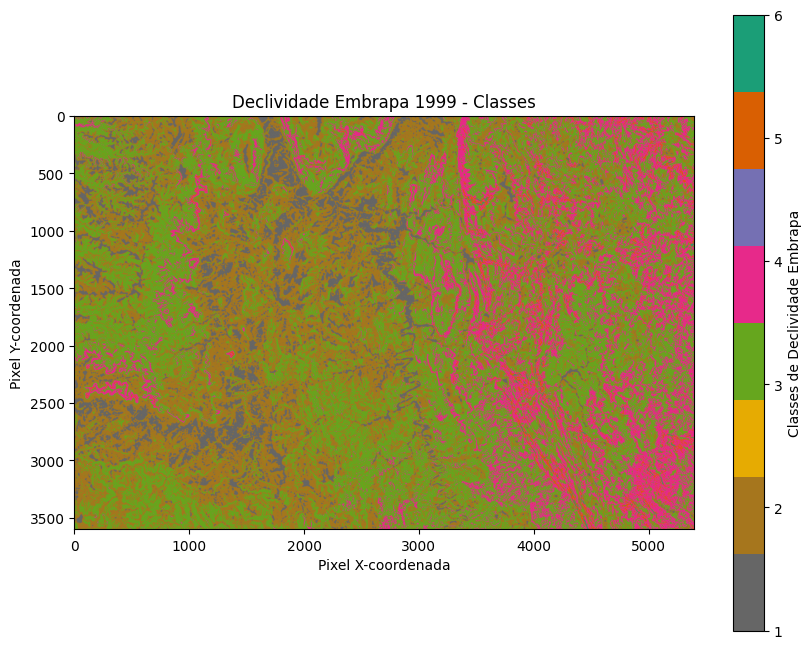

In [ ]:
# Visualizando
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 8)) # figura larga melhor visualização
plt.imshow(sc, cmap='Dark2_r', vmin=np.min(sc), vmax=np.max(sc))
plt.colorbar(label='Classes de Declividade Embrapa')
plt.title('Declividade Embrapa 1999 - Classes')
plt.xlabel('Pixel X-coordenada')
plt.ylabel('Pixel Y-coordenada')
plt.savefig('sc_declividade.png')
plt.show()

In [ ]:
# Tamanho do Pixel
with rio.open(assets['SC'].href) as sc_ds:
    sc = sc_ds.read(1)
    transform = sc_ds.transform

In [ ]:
# Projeção
from pyproj import Geod

geod = Geod(ellps="WGS84")

pixel_width = transform[0]
pixel_height = abs(transform[4])

# coordenada de referência
lon = transform[2]
lat = transform[5]

# calcula distância real
_, _, width_m = geod.inv(lon, lat, lon + pixel_width, lat)
_, _, height_m = geod.inv(lon, lat, lon, lat - pixel_height)

pixel_area_m2 = width_m * height_m

In [ ]:
# Pega Resolução
pixel_width = transform[0]
pixel_height = -transform[4]  # negativo por causa da orientação

pixel_area_m2 = pixel_width * pixel_height

In [ ]:
# Conta Pixel por classe
unique, counts = np.unique(sc, return_counts=True)

# Converter para Ha
# 1 hectare = 10.000 m²
area_ha = (counts * pixel_area_m2) / 10000

In [ ]:
# Saída Organizada

df = pd.DataFrame({
    'Classe_Declividade': unique,
    'Pixels': counts,
    'Area_ha': area_ha
})

print(df)

   Classe_Declividade   Pixels   Area_ha
0                   1  1740705  17407.05
1                   2  6402993  64029.93
2                   3  7791952  77919.52
3                   4  3101316  31013.16
4                   5   359718   3597.18
5                   6    43316    433.16


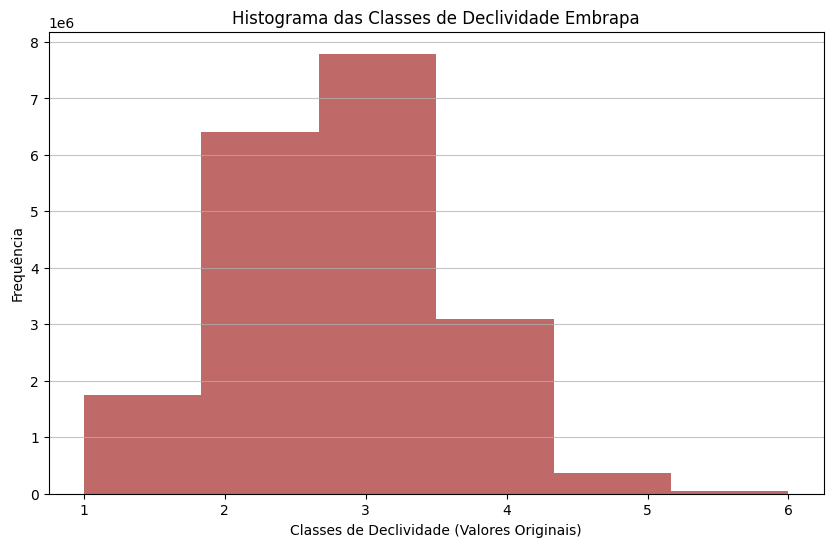

In [ ]:
# Histograma
plt.figure(figsize=(10, 6))
plt.hist(sc.flatten(), bins=len(np.unique(sc)), color='brown', alpha=0.7)
plt.title('Histograma das Classes de Declividade Embrapa')
plt.xlabel('Classes de Declividade (Valores Originais)')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# Pegando o Hilshade
rs_asset = assets['RS']

In [ ]:
# Abrindo
with rio.open(rs_asset.href) as rs_ds:
    rs = rs_ds.read(1)

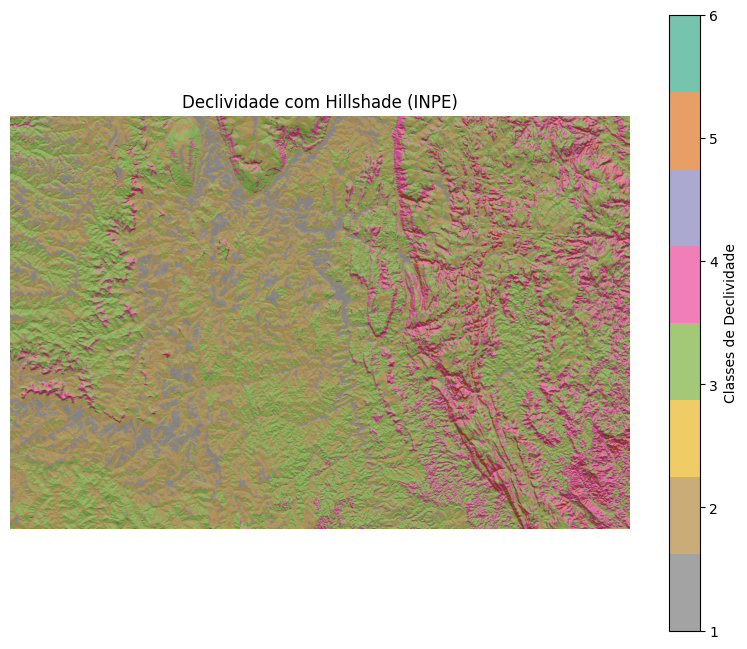

In [ ]:
# Polt
plt.figure(figsize=(10, 8))

# fundo = hillshade pronto
plt.imshow(rs, cmap='gray')

# overlay = declividade
plt.imshow(sc, cmap='Dark2_r', alpha=0.6)

plt.colorbar(label='Classes de Declividade')
plt.title('Declividade com Hillshade (INPE)')
plt.axis('off')
plt.savefig('declividade_com_hillshade.png')
plt.show()

In [ ]:
collection = service.get_collection('S2-16D-2')
collection

<CollectionClient id=S2-16D-2>

In [ ]:
# Pegando EVI da área

item_search = service.search(bbox=(-43.640826,-18.286098,-43.559527,-18.212019),
                             datetime='2018-08-01/2019-07-31',
                             collections=['S2-16D-2'],
                             query={"eo:cloud_cover": {"lt": 20}})
item_search
item_search.matched()

21

In [ ]:
# Get the first Sentinel-2 item from the search results
s2_items = list(item_search.items())

# Ensure there are Sentinel-2 items before proceeding
if s2_items:
    s2_item = s2_items[0]
    s2_assets = s2_item.assets

    # Assign EVI asset from Sentinel-2 item assets
    evi_asset = s2_assets['EVI']

    # Assign RS (hillshade) asset from the previously loaded Topodata item assets
    rs_asset = item.assets['RS']
else:
    print("No Sentinel-2 items found for the specified criteria.")
    evi_asset = None
    rs_asset = None # Or handle this case as appropriate

In [ ]:
# Lendo
import rasterio as rio

with rio.open(evi_asset.href) as evi_ds:
    evi = evi_ds.read(1).astype('float32')
    transform = evi_ds.transform

with rio.open(rs_asset.href) as rs_ds:
    rs = rs_ds.read(1)

In [ ]:
# Pro plot fica bom caso nao esteja (PREVENTIVO NÃO USAR SE O PLOT ESTIVER OK)
height, width = evi.shape

xmin = transform[2]
xmax = xmin + transform[0] * width
ymax = transform[5]
ymin = ymax + transform[4] * height

extent = [xmin, xmax, ymin, ymax]

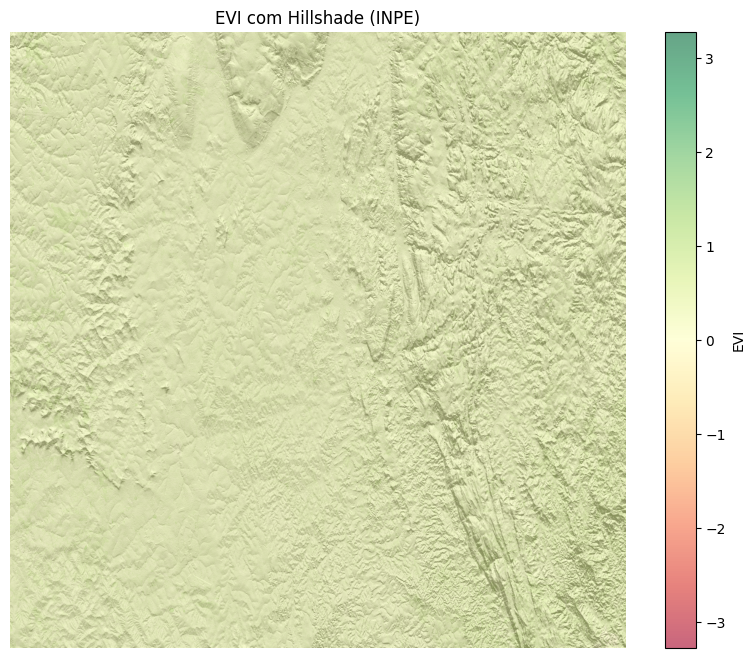

In [ ]:
# Plot

evi = evi / 10000

plt.figure(figsize=(10,8))

# hillshade
plt.imshow(rs, cmap='gray', extent=extent)

# EVI
plt.imshow(evi, cmap='RdYlGn', alpha=0.6, extent=extent)

plt.colorbar(label='EVI')
plt.title('EVI com Hillshade (INPE)')
plt.axis('off')
plt.savefig('evi_com_hillshade.png')
plt.show()

In [ ]:
# Classes e áreas ha
pixel_width = transform[0]
pixel_height = -transform[4]

pixel_area_m2 = pixel_width * pixel_height

In [ ]:
# Classificar EVI

bins = [-1, 0, 0.2, 0.4, 0.6, 1]

# Adjust labels to cover all possible indices from np.digitize (0 to 6)
labels = [
    "EVI <= -1 (Água/Sem vegetação)", # for evi_class == 0
    "Sem vegetação",                  # for evi_class == 1
    "Muito baixa",                    # for evi_class == 2
    "Moderada",                       # for evi_class == 3
    "Alta",                           # for evi_class == 4
    "Muito alta",                     # for evi_class == 5
    "EVI > 1 (Valores anormais)"      # for evi_class == 6
]

evi_class = np.digitize(evi, bins)

In [ ]:
# Organização
unique, counts = np.unique(evi_class, return_counts=True)

area_ha = (counts * pixel_area_m2) / 10000


df = pd.DataFrame({
    'Classe': unique,
    'Descricao': [labels[i] for i in unique], # Changed from labels[i-1] to labels[i]
    'Area_ha': area_ha
})

# percentual (nível pro)
df['Percentual_%'] = (df['Area_ha'] / df['Area_ha'].sum()) * 100

print(df)

   Classe                       Descricao    Area_ha  Percentual_%
0       0  EVI <= -1 (Água/Sem vegetação)       0.10      0.000009
1       1                   Sem vegetação     617.57      0.055381
2       2                     Muito baixa  323429.05     29.003552
3       3                        Moderada  694600.35     62.288398
4       4                            Alta   93563.07      8.390283
5       5                      Muito alta    2925.79      0.262371
6       6      EVI > 1 (Valores anormais)       0.07      0.000006


In [ ]:
# Garantindo mesmo Shape
print(sc.shape, evi_class.shape)

(3600, 5400) (10560, 10560)


In [ ]:
# Matriz d saída

resultado = np.zeros_like(sc)

In [ ]:
# Cruzamento
from rasterio.warp import reproject, Resampling

# Re-open the sc raster to get its transform, CRS and shape for reprojection target
with rasterio.open(assets['SC'].href) as sc_target_ds:
    sc_transform = sc_target_ds.transform
    sc_crs = sc_target_ds.crs
    sc_shape = sc_target_ds.shape

# Re-open the evi raster to get its transform and CRS for reprojection source
with rasterio.open(evi_asset.href) as evi_source_ds:
    evi_src_transform = evi_source_ds.transform
    evi_src_crs = evi_source_ds.crs

# Create an empty array for the resampled evi_class with the shape of sc
evi_class_resampled = np.empty(sc_shape, dtype=evi_class.dtype)

# Reproject evi_class to match sc's transform and shape
reproject(
    source=evi_class,
    destination=evi_class_resampled,
    src_transform=evi_src_transform,
    src_crs=evi_src_crs,
    dst_transform=sc_transform,
    dst_crs=sc_crs,
    resampling=Resampling.nearest # Use nearest neighbor for classification data
)

# Now, `resultado` should be initialized with the correct shape, which is `sc.shape`
resultado = np.zeros_like(sc, dtype=np.uint8)

# Área crítica (baixa vegetação + relevo acidentado)
resultado[(evi_class_resampled <= 2) & (sc >= 4)] = 3

# Atenção (condição intermediária)
resultado[(evi_class_resampled <= 3) & (sc >= 3)] = 2

# Estável (boa vegetação + relevo suave)
resultado[(evi_class_resampled >= 4) & (sc <= 2)] = 1

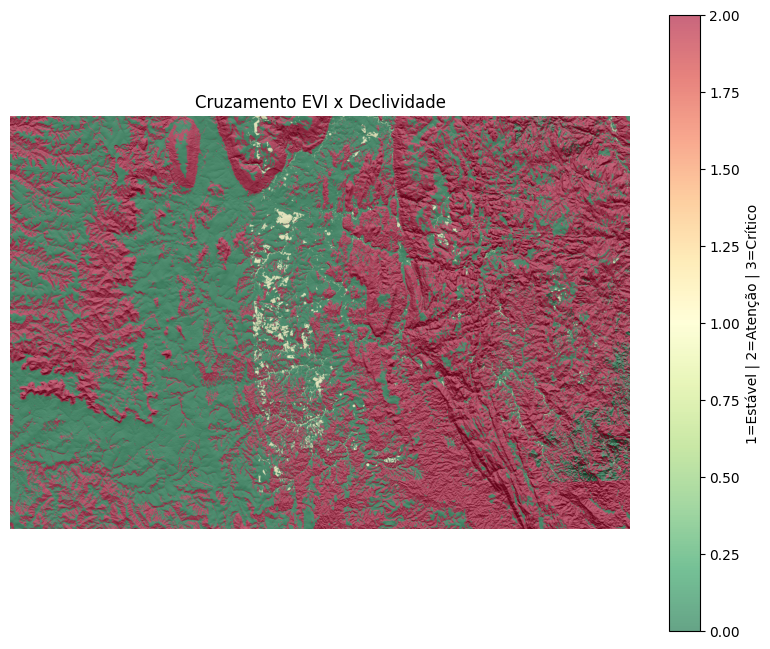

In [ ]:
# Plot

plt.figure(figsize=(10,8))

plt.imshow(rs, cmap='gray')
plt.imshow(resultado, cmap='RdYlGn_r', alpha=0.6)

plt.colorbar(label='1=Estável | 2=Atenção | 3=Crítico')
plt.title('Cruzamento EVI x Declividade')
plt.axis('off')
plt.savefig('cruzamento_evi_declividade.png')
plt.show()

In [ ]:
# Áreas em Ha
unique, counts = np.unique(resultado, return_counts=True)

area_ha = (counts * pixel_area_m2) / 10000

import pandas as pd

df = pd.DataFrame({
    'Classe': unique,
    'Descricao': ['Estável','Atenção','Crítico'][:len(unique)],
    'Area_ha': area_ha
})

df['Percentual_%'] = (df['Area_ha'] / df['Area_ha'].sum()) * 100

print(df)

   Classe Descricao    Area_ha  Percentual_%
0       0   Estável   83654.37     43.032083
1       1   Atenção    2548.76      1.311091
2       2   Crítico  108196.87     55.656826
